In [9]:
# Load topic data
import os
import pandas as pd

output_dir = './output'
file_path = os.path.join(output_dir, 'topics.csv')
topics = pd.read_csv(file_path, lineterminator='\n')

topic_names = topics['Name'].tolist()
topics

,Topic,Name,Words\r
0,0,Substance Use Disorder,"alcohol,opioid,substance,drinking,use,dependen..."
1,1,Gut-Brain Axis,"gut,microbiota,microbiome,probiotics,axis,inte..."
2,2,HIV/AIDS Management,"hiv,aids,antiretroviral,living,art,plwh,plhiv,..."
3,3,Suicidal behavior,"suicide,suicidal,ideation,attempts,nssi,attemp..."
4,4,Autism Spectrum Disorder,"autism,asd,autistic,spectrum,children,sensory,..."
...,...,...,...
968,968,Iron homeostasis and neurodegeneration,"iron,ferroptosis,lcn2,overload,labile,tbi,nrf2..."
969,969,Spinal pain management,"epidural,radicular,herniation,steroid,osteocho..."
970,970,Genetic Variants,"cnvs,variants,deletion,schizophrenia,deletions..."
971,971,Child Exposure to Domestic Violence,"domestic,violence,dv,children,exposed,actualiz..."


In [4]:
# Load document to topic map (binary matrix)

output_file_path = os.path.join('./output', 'binary_matrix.csv')
binary_df = pd.read_csv(output_file_path)

# Convert 'PubDate' to datetime
binary_df['PubDate'] = pd.to_datetime(binary_df['PubDate'], errors='coerce')

# Drop any rows where PubDate is NaT (invalid dates)
binary_df = binary_df.dropna(subset=['PubDate'])



In [38]:
#import random

# Select a subset of topics and abstracts for first visualisation experiment

seltopics = []
selabstracts = []
showtopicnames = []

for i in set([19, 127, 141, 102, 21, 247, 1, 101, 312, 157] + list(range(500))):
    topicn = topic_names[i]
    topicwords = topics.at[i,'Words\r']
    abstracts = [ a+' '+b for (a,b) in zip(binary_df.query(f"Topic{i}==1 and PubYear>2024")['PaperTitle'].values,binary_df.query(f"Topic{i}==1 and PubYear>2024")['Abstract'].values) ]
    print("Processing topic",i,":",topicn,",",len(abstracts),"abstracts.")
#    abstracts = random.sample(abstracts, 20)
    selabstracts.extend(abstracts)
    seltopics.extend(len(abstracts)*[topicn])
    if i in list(range(20))+[19, 127, 141, 102, 21, 247, 1, 101, 312, 157]:
        showtopicnames.append(topicn)


Processing topic 0 : Substance Use Disorder , 35 abstracts.
Processing topic 1 : Gut-Brain Axis , 75 abstracts.
Processing topic 2 : HIV/AIDS Management , 44 abstracts.
Processing topic 3 : Suicidal behavior , 55 abstracts.
Processing topic 4 : Autism Spectrum Disorder , 44 abstracts.
Processing topic 5 : Phytotherapy , 18 abstracts.
Processing topic 6 : Traumatic Brain Injury , 27 abstracts.
Processing topic 7 : Kidney disease treatment , 28 abstracts.
Processing topic 8 : Diabetes , 27 abstracts.
Processing topic 9 : Mindfulness Interventions , 28 abstracts.
Processing topic 10 : Cannabinoids , 18 abstracts.
Processing topic 11 : Epilepsy treatment , 30 abstracts.
Processing topic 12 : Sports Performance , 34 abstracts.
Processing topic 13 : Parkinson's Disease , 28 abstracts.
Processing topic 14 : Stroke recovery , 44 abstracts.
Processing topic 15 : Multiple Sclerosis , 21 abstracts.
Processing topic 16 : Sexual and Gender Minority Mental Health , 23 abstracts.
Processing topic 17 

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

# Step 1: Load pre-trained sentence embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')  # Fast and efficient model

# Step 2: Generate embeddings
embeddings = model.encode(selabstracts)

In [40]:
# Step 3: Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
embeddings_2d = tsne.fit_transform(embeddings)

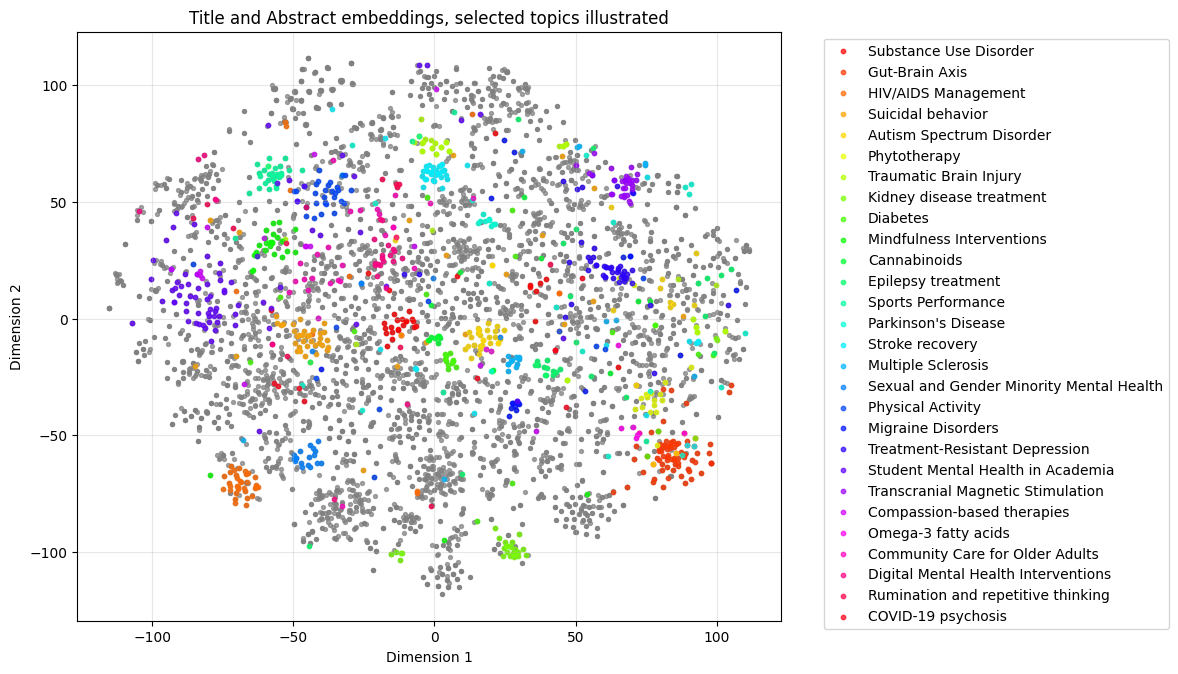

In [52]:
# Step 4: Plot
#import seaborn as sns

plt.figure(figsize=(12, 7))

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='grey', s=8, alpha=0.7)

colour_topics = showtopicnames
colors = plt.cm.hsv(np.linspace(0, 1, len(colour_topics)))
#colors = sns.color_palette("husl", n_colors=len(colour_topics))
topics_array = np.array(seltopics) 
for i, topic in enumerate(colour_topics):
    mask = topics_array == topic
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                label=topic, c=[colors[i]], s=10, alpha=0.7)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Title and Abstract embeddings, selected topics illustrated")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()  # Prevents legend from being cut off
plt.savefig('output/figs/titleabstractembeddings.svg', bbox_inches='tight')
plt.show()
